# Lab Day 2 — Backbone, công thức huấn luyện và suy luận trên DeepWeeds

Notebook **khung** cho Colab hoặc Kaggle. Các ô có chữ `TODO` là phần **bạn tự viết**; ô cài đặt, tải dữ liệu
và chạy `eval.py` đã viết sẵn. Đọc `README.md` (quy tắc chia dữ liệu, cách đánh giá), `GUIDE.md` và `RUBRIC.md` trước.

**Quy tắc quan trọng nhất:** chọn mọi thứ trên **val**; **test chỉ chạy một lần mỗi seed ở Bước 4**.

Bản đồ: Bước 0 (EDA, kiểm tra) → Bước 1 (backbone) → Bước 2 (công thức huấn luyện) → Bước 3 (suy luận)
→ Bước 4 (chung kết + `eval.py`) → Bước 5 (xlsx, biểu đồ, báo cáo).

## 0. Cài đặt môi trường

In [ ]:
!git clone https://github.com/Ataraxiza/K4-DAY02-NguyenTuanKhanh-2A202602819.git

Cloning into 'K4-DAY02-NguyenTuanKhanh-2A202602819'...
remote: Enumerating objects: 43, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 43 (delta 3), reused 3 (delta 1), pack-reused 31 (from 2)
Receiving objects: 100% (43/43), 69.28 KiB | 6.93 MiB/s, done.
Resolving deltas: 100% (9/9), done.


In [40]:
# Cài thư viện (Colab/Kaggle). Kaggle: bật Internet trong Settings.
#!pip -q install timm openpyxl

import sys, os, platform
import numpy as np, pandas as pd, torch, timm

# Đã `git clone` repo bài lab vào thư mục này (đổi nếu bạn đặt chỗ khác).
REPO_DIR = "K4-DAY02-NguyenTuanKhanh-2A202602819"
sys.path.insert(0, REPO_DIR)                 # để import eval.py
CODE_DIR = f"{REPO_DIR}/submissions/2A202602819_nguyen_tuan_khanh/code"
sys.path.insert(0, CODE_DIR)

print("python", platform.python_version(), "| torch", torch.__version__, "| timm", timm.__version__)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "KHÔNG CÓ GPU")

python 3.13.15 | torch 2.11.0+cu130 | timm 1.0.29
GPU: Tesla T4


### Tải dữ liệu (đã viết sẵn)
Ảnh từ Zenodo (~490 MB, kiểm tra MD5), nhãn và các file chia fold từ GitHub của tác giả.
**Sau khi giải nén, hãy `ls` để xem ảnh nằm ở thư mục nào** rồi đặt `IMAGES_DIR` cho đúng.

In [41]:
import hashlib

os.makedirs("data/labels", exist_ok=True)
if not os.path.exists("data/images.zip"):
    !wget -q -O data/images.zip "https://zenodo.org/records/7939060/files/images.zip?download=1"

h = hashlib.md5()
with open("data/images.zip", "rb") as f:
    for chunk in iter(lambda: f.read(1 << 20), b""):
        h.update(chunk)
assert h.hexdigest() == "b7b30f96d466fba86016aa5a26606e0f", f"MD5 sai: {h.hexdigest()}"

!unzip -q -n data/images.zip -d data/images
!ls data | head

BASE = "https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels"
for name in ["labels", "train_subset0", "val_subset0", "test_subset0"]:
    !wget -q -O data/labels/{name}.csv {BASE}/{name}.csv
!ls -la data/labels

images
images.zip
labels
total 1836
drwxr-xr-x 2 root root   4096 Oct  5 03:24 .
drwxr-xr-x 4 root root 843776 Oct  5 03:35 ..
-rw-r--r-- 1 root root 598898 Oct  5 07:28 labels.csv
-rw-r--r-- 1 root root  84183 Oct  5 07:28 test_subset0.csv
-rw-r--r-- 1 root root 252039 Oct  5 07:28 train_subset0.csv
-rw-r--r-- 1 root root  84039 Oct  5 07:28 val_subset0.csv


In [42]:
IMAGES_DIR = "data/images"
LABELS_DIR = "data/labels"

## Bước 0 — EDA và kiểm tra pipeline
Mục tiêu: hiểu dữ liệu, chạy các kiểm tra chia dữ liệu (README mục 2.1), kiểm tra pipeline trước khi chạy thật.

=== Split check ===

Số ảnh:
  train: 10501
  val  : 3501
  test : 3507

Số ảnh theo lớp:

train:
  0: Chinee Apple     -> 675
  1: Lantana          -> 637
  2: Parkinsonia      -> 618
  3: Parthenium       -> 613
  4: Prickly Acacia   -> 637
  5: Rubber Vine      -> 605
  6: Siam Weed        -> 644
  7: Snake Weed       -> 609
  8: Negatives        -> 5463

val:
  0: Chinee Apple     -> 225
  1: Lantana          -> 213
  2: Parkinsonia      -> 206
  3: Parthenium       -> 204
  4: Prickly Acacia   -> 212
  5: Rubber Vine      -> 202
  6: Siam Weed        -> 215
  7: Snake Weed       -> 203
  8: Negatives        -> 1821

test:
  0: Chinee Apple     -> 226
  1: Lantana          -> 213
  2: Parkinsonia      -> 207
  3: Parthenium       -> 205
  4: Prickly Acacia   -> 213
  5: Rubber Vine      -> 202
  6: Siam Weed        -> 215
  7: Snake Weed       -> 204
  8: Negatives        -> 1822

Overlap:
  train_val   : 0
  train_test  : 0
  val_test    : 0

Tổng ảnh duy nhất: 17509
Ảnh thiếu: 0


,Class,Train,Val,Test
0,Chinee Apple,675,225,226
1,Lantana,637,213,213
2,Parkinsonia,618,206,207
3,Parthenium,613,204,205
4,Prickly Acacia,637,212,213
5,Rubber Vine,605,202,202
6,Siam Weed,644,215,215
7,Snake Weed,609,203,204
8,Negatives,5463,1821,1822



=== IMBALANCE ===
Lớp lớn nhất : Negatives (9,106)
Lớp nhỏ nhất : Rubber Vine (1,009)
Tỷ lệ lớn nhất / nhỏ nhất: 9.02x


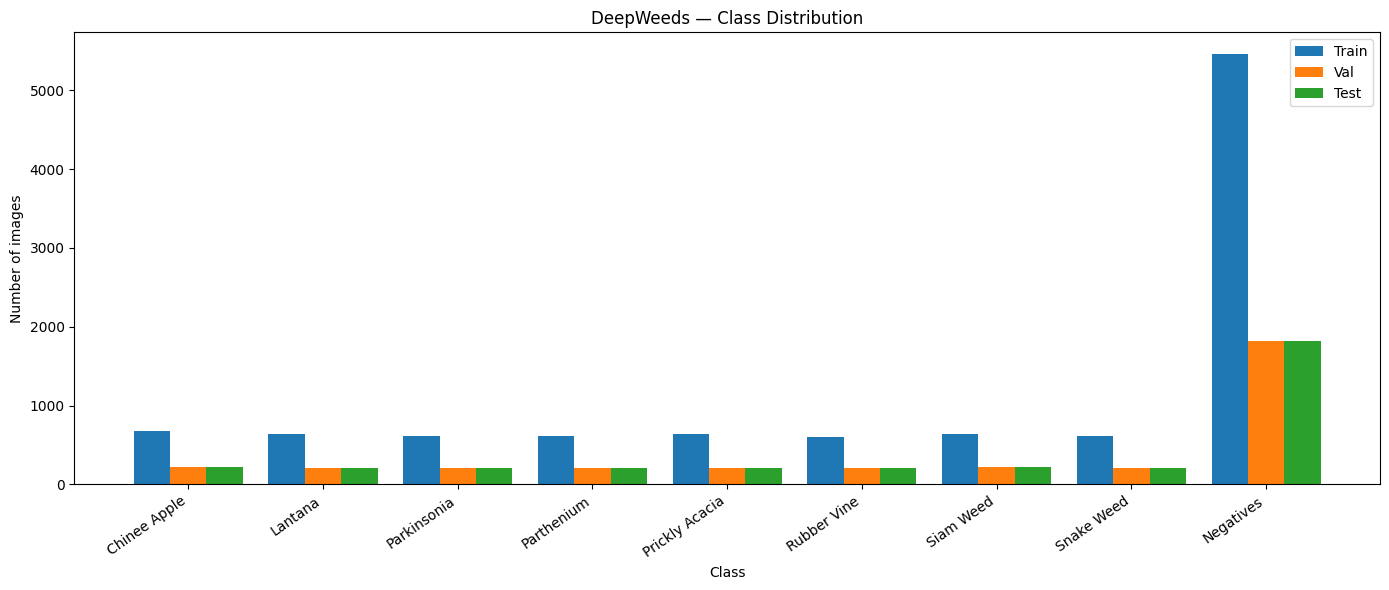

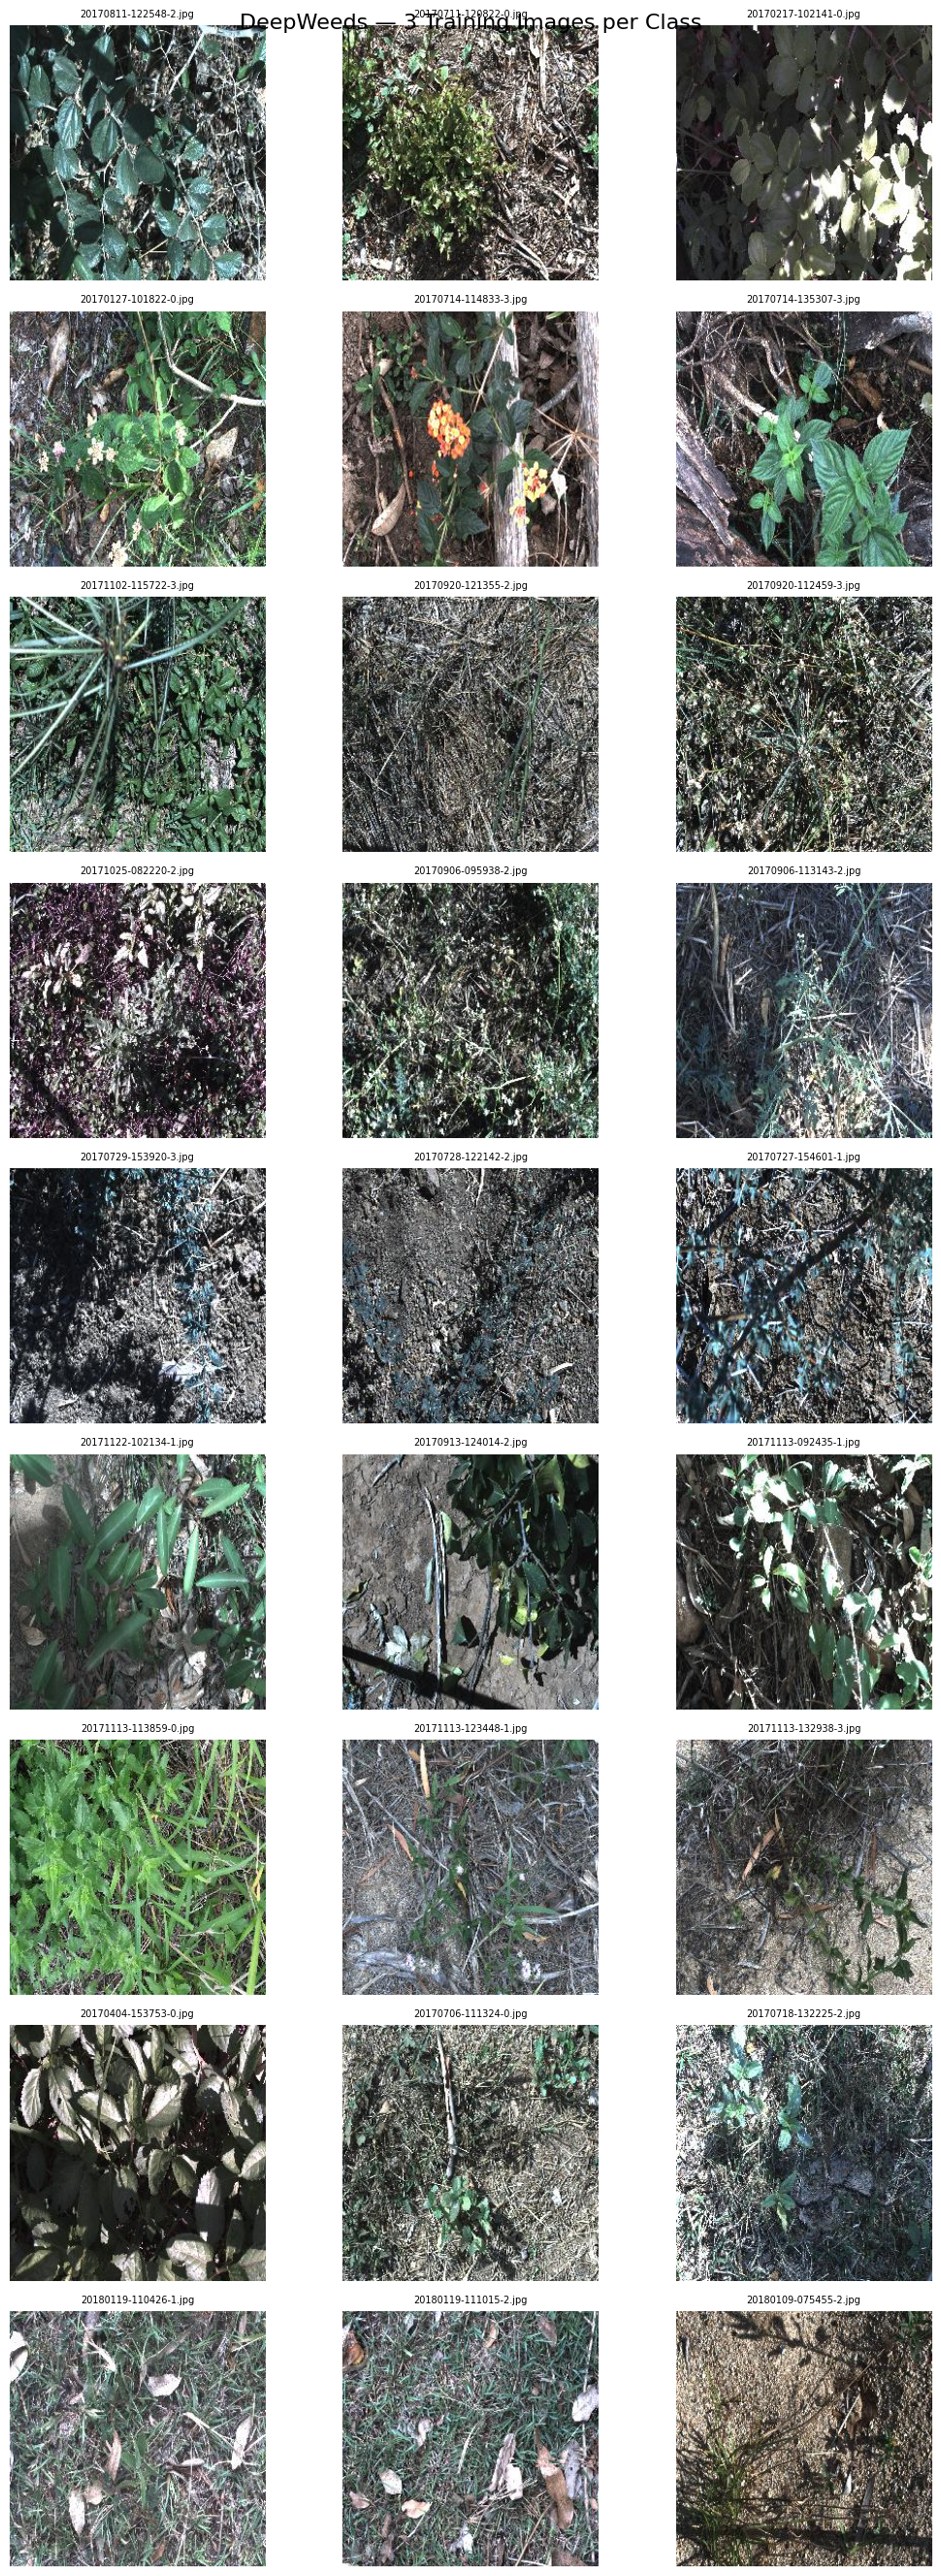

In [ ]:
# ============================================================
# BƯỚC 0.1 — EDA + kiểm tra split
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Load fold 0
train_df, val_df, test_df = dataset.load_split(
    LABELS_DIR,
    fold=0,
)

# Kiểm tra bắt buộc: overlap, tổng 17,509 ảnh, file ảnh tồn tại
split_report = dataset.check_split(
    train_df,
    val_df,
    test_df,
    IMAGES_DIR,
)

print("\n=== SỐ ẢNH MỖI TẬP ===")
print(f"Train: {len(train_df):,}")
print(f"Val:   {len(val_df):,}")
print(f"Test:  {len(test_df):,}")
print(f"Total: {len(train_df) + len(val_df) + len(test_df):,}")

# ------------------------------------------------------------
# Số ảnh mỗi lớp
# ------------------------------------------------------------
def get_class_counts(df):
    return (
        df["Label"]
        .value_counts()
        .reindex(range(dataset.NUM_CLASSES), fill_value=0)
    )

train_counts = get_class_counts(train_df)
val_counts = get_class_counts(val_df)
test_counts = get_class_counts(test_df)

distribution = pd.DataFrame({
    "Class": dataset.CLASS_NAMES,
    "Train": train_counts.values,
    "Val": val_counts.values,
    "Test": test_counts.values,
})

print("\n=== PHÂN BỐ LỚP ===")
display(distribution)

# ------------------------------------------------------------
# Đối chiếu với Table 1 / kiểm tra imbalance
# ------------------------------------------------------------
all_counts = (
    pd.concat([train_df, val_df, test_df])["Label"]
    .value_counts()
    .reindex(range(dataset.NUM_CLASSES), fill_value=0)
)

print("\n=== IMBALANCE ===")
largest_label = int(all_counts.idxmax())
smallest_label = int(all_counts.idxmin())

print(
    f"Lớp lớn nhất : {dataset.CLASS_NAMES[largest_label]} "
    f"({all_counts[largest_label]:,})"
)
print(
    f"Lớp nhỏ nhất : {dataset.CLASS_NAMES[smallest_label]} "
    f"({all_counts[smallest_label]:,})"
)
print(
    f"Tỷ lệ lớn nhất / nhỏ nhất: "
    f"{all_counts[largest_label] / all_counts[smallest_label]:.2f}x"
)

# ------------------------------------------------------------
# Biểu đồ phân bố lớp
# ------------------------------------------------------------
x = np.arange(dataset.NUM_CLASSES)
width = 0.27

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(x - width, train_counts.values, width, label="Train")
ax.bar(x,         val_counts.values,   width, label="Val")
ax.bar(x + width, test_counts.values,  width, label="Test")

ax.set_title("DeepWeeds — Class Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Number of images")
ax.set_xticks(x)
ax.set_xticklabels(dataset.CLASS_NAMES, rotation=35, ha="right")
ax.legend()

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Xem >= 3 ảnh mỗi lớp
# ------------------------------------------------------------
fig, axes = plt.subplots(
    dataset.NUM_CLASSES,
    3,
    figsize=(11, 27),
)

for label in range(dataset.NUM_CLASSES):

    samples = train_df[
        train_df["Label"] == label
    ].sample(
        n=min(3, (train_df["Label"] == label).sum()),
        random_state=42,
    )

    for j, (_, row) in enumerate(samples.iterrows()):

        filename = str(row["Filename"])
        image_path = os.path.join(IMAGES_DIR, filename)

        image = Image.open(image_path).convert("RGB")

        axes[label, j].imshow(image)
        axes[label, j].axis("off")
        axes[label, j].set_title(
            filename,
            fontsize=7,
        )

        if j == 0:
            axes[label, j].set_ylabel(
                dataset.CLASS_NAMES[label],
                fontsize=10,
            )

plt.suptitle(
    "DeepWeeds — 3 Training Images per Class",
    fontsize=16,
)

plt.tight_layout()
plt.show()

Seed: 42
Device: cuda
GPU: Tesla T4

=== BATCH CHECK ===
Image shape: (8, 3, 224, 224)
Image dtype: torch.float32
Labels: [8, 7, 8, 8, 2, 0, 3, 6]
First filenames: ['20171212-101503-3.jpg', '20170304-130551-0.jpg', '20180112-074017-1.jpg']


model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            


=== INITIAL LOSS CHECK ===
Initial CE loss : 2.1919
-ln(1/9)        : 2.1972
step   0 | loss = 2.181829
step  10 | loss = 0.101818
step  20 | loss = 0.002796
step  30 | loss = 0.000515
step  40 | loss = 0.000242
step  50 | loss = 0.000171
step  60 | loss = 0.000144
step  70 | loss = 0.000130
step  80 | loss = 0.000121
step  90 | loss = 0.000113

=== OVERFIT CHECK ===
Initial loss: 2.181829
Final loss:   0.000107
Accuracy:     1.0000


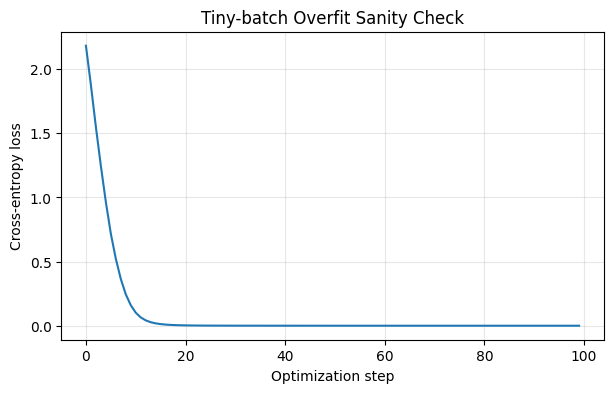

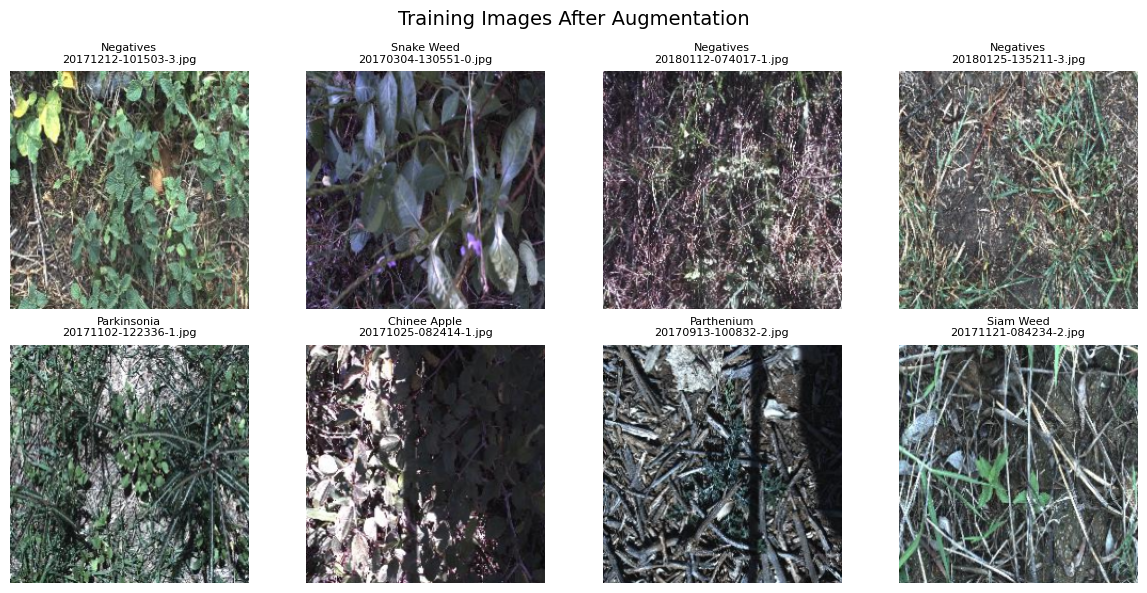


=== PIPELINE CHECK COMPLETE ===


In [ ]:
# ============================================================
# BƯỚC 0.2 — PIPELINE SANITY CHECK
# ============================================================

import random
import numpy as np
import torch
import torch.nn as nn
import timm
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Cố định seed
# ------------------------------------------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Seed:", SEED)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# ------------------------------------------------------------
# 2. Tạo transform + loader
# ------------------------------------------------------------
train_transform = dataset.build_transforms(
    train=True,
    img_size=224,
    aug="basic",
)

train_loader = dataset.make_loader(
    df=train_df,
    images_dir=IMAGES_DIR,
    transform=train_transform,
    batch_size=8,
    train=True,
    sampler=None,
    num_workers=2,
)

images, labels, filenames = next(iter(train_loader))

print("\n=== BATCH CHECK ===")
print("Image shape:", tuple(images.shape))
print("Image dtype:", images.dtype)
print("Labels:", labels.tolist())
print("First filenames:", list(filenames)[:3])

# ------------------------------------------------------------
# 3. Initial loss của model với head 9 lớp
# ------------------------------------------------------------
model = timm.create_model(
    "resnet50",
    pretrained=True,
    num_classes=dataset.NUM_CLASSES,
)

model = model.to(device)
model.train()

criterion = nn.CrossEntropyLoss()

images_device = images.to(device)
labels_device = labels.to(device)

with torch.no_grad():
    logits = model(images_device)
    initial_loss = criterion(
        logits,
        labels_device,
    )

expected_loss = -np.log(1 / dataset.NUM_CLASSES)

print("\n=== INITIAL LOSS CHECK ===")
print(f"Initial CE loss : {initial_loss.item():.4f}")
print(f"-ln(1/9)        : {expected_loss:.4f}")

# ------------------------------------------------------------
# 4. Overfit một batch nhỏ
# ------------------------------------------------------------
overfit_model = timm.create_model(
    "resnet50",
    pretrained=True,
    num_classes=dataset.NUM_CLASSES,
)

overfit_model = overfit_model.to(device)

optimizer = torch.optim.AdamW(
    overfit_model.parameters(),
    lr=1e-3,
    weight_decay=0.0,
)

overfit_images = images.to(device)
overfit_labels = labels.to(device)

loss_history = []

overfit_model.train()

for step in range(100):

    optimizer.zero_grad(set_to_none=True)

    logits = overfit_model(overfit_images)
    loss = criterion(logits, overfit_labels)

    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if step % 10 == 0:
        print(
            f"step {step:3d} | "
            f"loss = {loss.item():.6f}"
        )

# Kiểm tra prediction sau khi overfit
overfit_model.eval()

with torch.no_grad():
    logits = overfit_model(overfit_images)
    predictions = logits.argmax(dim=1)

overfit_accuracy = (
    predictions == overfit_labels
).float().mean().item()

print("\n=== OVERFIT CHECK ===")
print(f"Initial loss: {loss_history[0]:.6f}")
print(f"Final loss:   {loss_history[-1]:.6f}")
print(f"Accuracy:     {overfit_accuracy:.4f}")

# Vẽ loss
plt.figure(figsize=(7, 4))
plt.plot(loss_history)
plt.xlabel("Optimization step")
plt.ylabel("Cross-entropy loss")
plt.title("Tiny-batch Overfit Sanity Check")
plt.grid(alpha=0.3)
plt.show()

# ------------------------------------------------------------
# 5. Visualize ảnh sau augmentation
# ------------------------------------------------------------
def denormalize(images):
    mean = torch.tensor(
        dataset.IMAGENET_MEAN,
        dtype=images.dtype,
    ).view(1, 3, 1, 1)

    std = torch.tensor(
        dataset.IMAGENET_STD,
        dtype=images.dtype,
    ).view(1, 3, 1, 1)

    return (images.cpu() * std + mean).clamp(0, 1)


display_images = denormalize(images)

fig, axes = plt.subplots(
    2,
    4,
    figsize=(12, 6),
)

for i, ax in enumerate(axes.flat):

    image = display_images[i]

    ax.imshow(
        image.permute(1, 2, 0)
    )

    ax.set_title(
        f"{dataset.CLASS_NAMES[int(labels[i])]}\n"
        f"{filenames[i]}",
        fontsize=8,
    )

    ax.axis("off")

plt.suptitle(
    "Training Images After Augmentation",
    fontsize=14,
)

plt.tight_layout()
plt.show()

print("\n=== PIPELINE CHECK COMPLETE ===")

## Bước 1 — So sánh backbone (≥ 5)
Cùng công thức nền `T00` (GUIDE.md mục 1.4), cùng seed, mỗi backbone một lần chạy. Mã thí nghiệm `B01`, `B02`, ...

In [ ]:
# ============================================================
# Benchmark các backbone cho thí nghiệm B01
# ============================================================

from train import Config, run
import pandas as pd
import numpy as np


# ------------------------------------------------------------
# 1. Danh sách backbone cần benchmark
# ------------------------------------------------------------
#
# Nếu rubric của bạn yêu cầu danh sách khác thì chỉ cần sửa
# biến BACKBONES, không cần sửa train.run().
#

BACKBONES = [
    "resnet18",
    "resnet50",
    "efficientnet_b0",
]


# ------------------------------------------------------------
# 2. Chạy từng backbone
# ------------------------------------------------------------

results = []

for backbone in BACKBONES:

    print("=" * 70)
    print(f"Running B01 | backbone={backbone} | seed=0")
    print("=" * 70)

    cfg = Config(
        exp_id="B01",
        backbone=backbone,
        seed=0,
    )

    summary = run(cfg)

    # Tag trọng số / pretrained setting.
    #
    # Ở Config mặc định:
    #     init="finetune"
    #
    # Nếu muốn ghi rõ hơn trong bảng:
    weight_tag = cfg.init

    results.append({
        "tag": weight_tag,
        "backbone": backbone,

        "#params (M)": summary["params_m"],
        "GMAC": summary["gmacs"],

        "macro-F1 val": summary["val_macro_f1"],
        "top-1 val": summary["val_top1"],

        "time/epoch (s)": summary[
            "train_time_per_epoch"
        ],

        "best_epoch": summary[
            "best_epoch"
        ],
    })


# ------------------------------------------------------------
# 3. Tạo bảng benchmark
# ------------------------------------------------------------

benchmark_df = pd.DataFrame(results)

# Sắp xếp theo macro-F1 giảm dần.
benchmark_df = benchmark_df.sort_values(
    by="macro-F1 val",
    ascending=False,
).reset_index(drop=True)


# Hiển thị đẹp hơn.
display(
    benchmark_df.style.format({
        "#params (M)": "{:.2f}",
        "GMAC": "{:.2f}",
        "macro-F1 val": "{:.4f}",
        "top-1 val": "{:.4f}",
        "time/epoch (s)": "{:.2f}",
    })
)


# ------------------------------------------------------------
# 4. Lưu bảng kết quả
# ------------------------------------------------------------

benchmark_df.to_csv(
    "B01_backbone_results.csv",
    index=False,
)

print("\nĐã lưu: B01_backbone_results.csv")


# ------------------------------------------------------------
# 5. Chọn 1-2 backbone đi tiếp
# ------------------------------------------------------------
#
# Tiêu chí chính:
#   1. macro-F1 val cao hơn
#   2. nếu F1 gần nhau, ưu tiên model nhẹ hơn
#
# Ta coi chênh lệch <= 0.005 là "gần tương đương".
# Có thể đổi ngưỡng này nếu rubric yêu cầu.
# ------------------------------------------------------------

if len(benchmark_df) == 0:
    raise RuntimeError(
        "Không có kết quả benchmark."
    )

best_row = benchmark_df.iloc[0]

selected = [best_row["backbone"]]

best_f1 = float(
    best_row["macro-F1 val"]
)

# Tìm backbone khác có F1 gần best nhưng nhẹ hơn đáng kể.
for _, row in benchmark_df.iloc[1:].iterrows():

    f1 = float(
        row["macro-F1 val"]
    )

    params = float(
        row["#params (M)"]
    )

    best_params = float(
        best_row["#params (M)"]
    )

    # F1 gần model tốt nhất.
    f1_close = (
        best_f1 - f1 <= 0.005
    )

    # Có lợi thế đáng kể về kích thước.
    much_smaller = (
        params <= best_params * 0.75
    )

    if f1_close and much_smaller:
        selected.append(
            row["backbone"]
        )
        break

    # Tối đa 2 backbone.
    if len(selected) >= 2:
        break


# ------------------------------------------------------------
# 6. In lý do lựa chọn
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("BACKBONE ĐƯỢC CHỌN ĐỂ ĐI TIẾP")
print("=" * 70)

for backbone in selected:

    row = benchmark_df[
        benchmark_df["backbone"] == backbone
    ].iloc[0]

    print(
        f"\n- {backbone}"
    )

    print(
        f"  macro-F1 val = "
        f"{row['macro-F1 val']:.4f}"
    )

    print(
        f"  top-1 val    = "
        f"{row['top-1 val']:.4f}"
    )

    print(
        f"  params       = "
        f"{row['#params (M)']:.2f} M"
    )

    print(
        f"  GMAC         = "
        f"{row['GMAC']:.2f}"
    )

    print(
        f"  time/epoch   = "
        f"{row['time/epoch (s)']:.2f} s"
    )


# ------------------------------------------------------------
# 7. Tự sinh nhận xét để đưa vào report
# ------------------------------------------------------------

best_backbone = benchmark_df.iloc[0]["backbone"]
best_f1 = float(
    benchmark_df.iloc[0]["macro-F1 val"]
)

best_top1 = float(
    benchmark_df.iloc[0]["top-1 val"]
)

best_params = float(
    benchmark_df.iloc[0]["#params (M)"]
)

best_gmac = float(
    benchmark_df.iloc[0]["GMAC"]
)

print("\n" + "=" * 70)
print("NHẬN XÉT")
print("=" * 70)

print(
    f"Backbone có macro-F1 validation cao nhất là "
    f"{best_backbone} "
    f"({best_f1:.4f}), với top-1 = {best_top1:.4f}, "
    f"{best_params:.2f}M parameters và "
    f"{best_gmac:.2f} GMAC."
)

if len(selected) == 2:

    second = selected[1]

    second_row = benchmark_df[
        benchmark_df["backbone"] == second
    ].iloc[0]

    print(
        f"Ngoài {best_backbone}, chọn thêm {second} "
        f"vì macro-F1 ({second_row['macro-F1 val']:.4f}) "
        f"gần mức tốt nhất nhưng có chi phí tính toán/"
        f"số tham số thấp hơn, phù hợp để tiếp tục "
        f"các thí nghiệm T/F."
    )

else:

    print(
        f"Chỉ chọn {best_backbone} để đi tiếp vì đây là "
        f"backbone có macro-F1 validation tốt nhất và "
        f"chưa có backbone khác vừa đạt F1 đủ gần vừa "
        f"có lợi thế rõ rệt về chi phí tính toán."
    )


# ------------------------------------------------------------
# 8. Biến này có thể dùng trực tiếp ở các cell T/F sau
# ------------------------------------------------------------

SELECTED_BACKBONES = selected

print(
    "\nSELECTED_BACKBONES =",
    SELECTED_BACKBONES,
)

Running B01 | backbone=resnet18 | seed=0
=== Split check ===

Số ảnh:
  train: 10501
  val  : 3501
  test : 3507

Số ảnh theo lớp:

train:
  0: Chinee Apple     -> 675
  1: Lantana          -> 637
  2: Parkinsonia      -> 618
  3: Parthenium       -> 613
  4: Prickly Acacia   -> 637
  5: Rubber Vine      -> 605
  6: Siam Weed        -> 644
  7: Snake Weed       -> 609
  8: Negatives        -> 5463

val:
  0: Chinee Apple     -> 225
  1: Lantana          -> 213
  2: Parkinsonia      -> 206
  3: Parthenium       -> 204
  4: Prickly Acacia   -> 212
  5: Rubber Vine      -> 202
  6: Siam Weed        -> 215
  7: Snake Weed       -> 203
  8: Negatives        -> 1821

test:
  0: Chinee Apple     -> 226
  1: Lantana          -> 213
  2: Parkinsonia      -> 207
  3: Parthenium       -> 205
  4: Prickly Acacia   -> 213
  5: Rubber Vine      -> 202
  6: Siam Weed        -> 215
  7: Snake Weed       -> 204
  8: Negatives        -> 1822

Overlap:
  train_val   : 0
  train_test  : 0
  val_test    : 

/content/K4-DAY02-NguyenTuanKhanh-2A202602819/submissions/2A202602819_nguyen_tuan_khanh/code/train.py:314: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=cfg.amp and device.type == 'cuda')


Running B01 | backbone=resnet50 | seed=0
=== Split check ===

Số ảnh:
  train: 10501
  val  : 3501
  test : 3507

Số ảnh theo lớp:

train:
  0: Chinee Apple     -> 675
  1: Lantana          -> 637
  2: Parkinsonia      -> 618
  3: Parthenium       -> 613
  4: Prickly Acacia   -> 637
  5: Rubber Vine      -> 605
  6: Siam Weed        -> 644
  7: Snake Weed       -> 609
  8: Negatives        -> 5463

val:
  0: Chinee Apple     -> 225
  1: Lantana          -> 213
  2: Parkinsonia      -> 206
  3: Parthenium       -> 204
  4: Prickly Acacia   -> 212
  5: Rubber Vine      -> 202
  6: Siam Weed        -> 215
  7: Snake Weed       -> 203
  8: Negatives        -> 1821

test:
  0: Chinee Apple     -> 226
  1: Lantana          -> 213
  2: Parkinsonia      -> 207
  3: Parthenium       -> 205
  4: Prickly Acacia   -> 213
  5: Rubber Vine      -> 202
  6: Siam Weed        -> 215
  7: Snake Weed       -> 204
  8: Negatives        -> 1822

Overlap:
  train_val   : 0
  train_test  : 0
  val_test    : 

/content/K4-DAY02-NguyenTuanKhanh-2A202602819/submissions/2A202602819_nguyen_tuan_khanh/code/train.py:314: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=cfg.amp and device.type == 'cuda')


Running B01 | backbone=efficientnet_b0 | seed=0
=== Split check ===

Số ảnh:
  train: 10501
  val  : 3501
  test : 3507

Số ảnh theo lớp:

train:
  0: Chinee Apple     -> 675
  1: Lantana          -> 637
  2: Parkinsonia      -> 618
  3: Parthenium       -> 613
  4: Prickly Acacia   -> 637
  5: Rubber Vine      -> 605
  6: Siam Weed        -> 644
  7: Snake Weed       -> 609
  8: Negatives        -> 5463

val:
  0: Chinee Apple     -> 225
  1: Lantana          -> 213
  2: Parkinsonia      -> 206
  3: Parthenium       -> 204
  4: Prickly Acacia   -> 212
  5: Rubber Vine      -> 202
  6: Siam Weed        -> 215
  7: Snake Weed       -> 203
  8: Negatives        -> 1821

test:
  0: Chinee Apple     -> 226
  1: Lantana          -> 213
  2: Parkinsonia      -> 207
  3: Parthenium       -> 205
  4: Prickly Acacia   -> 213
  5: Rubber Vine      -> 202
  6: Siam Weed        -> 215
  7: Snake Weed       -> 204
  8: Negatives        -> 1822

Overlap:
  train_val   : 0
  train_test  : 0
  val_tes

model.safetensors: reconstructing file:   0%|          |  0.00B / 21.4MB            

model.safetensors: downloading bytes:           |  0.00B            

/content/K4-DAY02-NguyenTuanKhanh-2A202602819/submissions/2A202602819_nguyen_tuan_khanh/code/train.py:314: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=cfg.amp and device.type == 'cuda')
/content/K4-DAY02-NguyenTuanKhanh-2A202602819/submissions/2A202602819_nguyen_tuan_khanh/code/train.py:190: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


,tag,backbone,#params (M),GMAC,macro-F1 val,top-1 val,time/epoch (s),best_epoch
0,finetune,efficientnet_b0,4.02,0.44,0.8548,0.8900,55.98,12
1,finetune,resnet50,23.53,6.41,0.8094,0.8626,63.19,12
2,finetune,resnet18,11.18,2.75,0.7755,0.8320,52.55,11



Đã lưu: B01_backbone_results.csv

BACKBONE ĐƯỢC CHỌN ĐỂ ĐI TIẾP

- efficientnet_b0
  macro-F1 val = 0.8548
  top-1 val    = 0.8900
  params       = 4.02 M
  GMAC         = 0.44
  time/epoch   = 55.98 s

NHẬN XÉT
Backbone có macro-F1 validation cao nhất là efficientnet_b0 (0.8548), với top-1 = 0.8900, 4.02M parameters và 0.44 GMAC.
Chỉ chọn efficientnet_b0 để đi tiếp vì đây là backbone có macro-F1 validation tốt nhất và chưa có backbone khác vừa đạt F1 đủ gần vừa có lợi thế rõ rệt về chi phí tính toán.

SELECTED_BACKBONES = ['efficientnet_b0']


## Bước 2 — Công thức huấn luyện (≥ 3 trục)
Mỗi lần chạy chỉ khác `T00` **một yếu tố**. Mã `T01`, `T02`, ... Ghi rõ khác ở điểm nào.

In [ ]:
# ============================================================
# BƯỚC 2 — THỬ NGHIỆM HÓA CÔNG THỨC HUẤN LUYỆN (A–G)
# ============================================================
# Mục tiêu: chỉ thay đổi 1 yếu tố mỗi lần so với T00.
# Dùng để đánh giá các trục: khởi tạo, augmentation, loss,
# sampler, LR/optimizer, EMA, ...

from dataclasses import asdict
from pathlib import Path

BASE_CFG = Config(
    exp_id="T00",
    backbone="resnet50",
    init="finetune",
    seed=0,
    epochs=12,
    batch_size=64,
    lr_backbone=1e-4,
    lr_head=1e-3,
    weight_decay=0.05,
    warmup_epochs=1.0,
    amp=True,
    aug="basic",
    loss="ce",
    label_smoothing=0.0,
    focal_gamma=2.0,
    class_weight_beta=None,
    ema_decay=None,
    mix=None,
    mix_alpha=1.0,
    sampler=None,
)

# Các thí nghiệm cần thử theo từng trục.
# Chú ý: mỗi cấu hình chỉ thay 1-2 yếu tố so với BASE_CFG.
TRAINING_ABLATIONS = {
    "T00": dict(),
    "T01_frozen_backbone": {
        "exp_id": "T01",
        "init": "frozen",
    },
    "T02_label_smoothing": {
        "exp_id": "T02",
        "label_smoothing": 0.1,
    },
    "T03_focal": {
        "exp_id": "T03",
        "loss": "focal",
        "focal_gamma": 2.0,
    },
    "T04_cutmix": {
        "exp_id": "T04",
        "mix": "cutmix",
        "mix_alpha": 1.0,
    },
    "T05_ema": {
        "exp_id": "T05",
        "ema_decay": 0.999,
    },
    "T06_augment_strong": {
        "exp_id": "T06",
        "aug": "randaug",
    },
}

# Mỗi thí nghiệm: chạy 1 seed rồi so sánh với T00.
# Nếu cần tăng độ tin cậy, lặp lại với seed khác rồi báo cáo mean ± std.
training_rows = []
base_summary = None

for name, overrides in TRAINING_ABLATIONS.items():
    cfg = Config(**{**asdict(BASE_CFG), **overrides})
    cfg.seed = 0
    cfg.exp_id = name

    print("=" * 80)
    print(f"Running {name} | backbone={cfg.backbone} | seed={cfg.seed}")
    print("=" * 80)

    summary = run(cfg)
    summary["exp_id"] = name
    summary["val_macro_f1"] = float(summary["val_macro_f1"])
    summary["val_top1"] = float(summary["val_top1"])
    summary["train_time_per_epoch"] = float(summary["train_time_per_epoch"])
    summary["best_epoch"] = int(summary["best_epoch"])

    if name == "T00":
        base_summary = summary

    training_rows.append(summary)

training_df = pd.DataFrame(training_rows)
if base_summary is not None:
    training_df["delta_vs_T00"] = (
        training_df["val_macro_f1"] - float(base_summary["val_macro_f1"])
    )

print("\n=== BẢNG SO SÁNH CÁC TRỤC HUẤN LUYỆN ===")
display(training_df[["exp_id", "val_macro_f1", "val_top1", "best_epoch", "delta_vs_T00"]].sort_values("val_macro_f1", ascending=False))

# Ví dụ: thử kết hợp các yếu tố tốt nhất, chỉ sau khi thấy chiếm ưu rõ rệt.
# Nếu T03/T04/T05 cho thấy cải thiện, cho phép tạo config kết hợp:
BEST_COMBO = Config(
    exp_id="T07_combo",
    backbone="resnet50",
    init="finetune",
    loss="focal",
    mix="cutmix",
    ema_decay=0.999,
    label_smoothing=0.1,
    seed=0,
)
summary_combo = run(BEST_COMBO)
print("Combo tốt nhất:", summary_combo["val_macro_f1"])

Running T00 | backbone=resnet50 | seed=0
=== Split check ===

Số ảnh:
  train: 10501
  val  : 3501
  test : 3507

Số ảnh theo lớp:

train:
  0: Chinee Apple     -> 675
  1: Lantana          -> 637
  2: Parkinsonia      -> 618
  3: Parthenium       -> 613
  4: Prickly Acacia   -> 637
  5: Rubber Vine      -> 605
  6: Siam Weed        -> 644
  7: Snake Weed       -> 609
  8: Negatives        -> 5463

val:
  0: Chinee Apple     -> 225
  1: Lantana          -> 213
  2: Parkinsonia      -> 206
  3: Parthenium       -> 204
  4: Prickly Acacia   -> 212
  5: Rubber Vine      -> 202
  6: Siam Weed        -> 215
  7: Snake Weed       -> 203
  8: Negatives        -> 1821

test:
  0: Chinee Apple     -> 226
  1: Lantana          -> 213
  2: Parkinsonia      -> 207
  3: Parthenium       -> 205
  4: Prickly Acacia   -> 213
  5: Rubber Vine      -> 202
  6: Siam Weed        -> 215
  7: Snake Weed       -> 204
  8: Negatives        -> 1822

Overlap:
  train_val   : 0
  train_test  : 0
  val_test    : 

/content/K4-DAY02-NguyenTuanKhanh-2A202602819/submissions/2A202602819_nguyen_tuan_khanh/code/train.py:314: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=cfg.amp and device.type == 'cuda')


Running T01_frozen_backbone | backbone=resnet50 | seed=0
=== Split check ===

Số ảnh:
  train: 10501
  val  : 3501
  test : 3507

Số ảnh theo lớp:

train:
  0: Chinee Apple     -> 675
  1: Lantana          -> 637
  2: Parkinsonia      -> 618
  3: Parthenium       -> 613
  4: Prickly Acacia   -> 637
  5: Rubber Vine      -> 605
  6: Siam Weed        -> 644
  7: Snake Weed       -> 609
  8: Negatives        -> 5463

val:
  0: Chinee Apple     -> 225
  1: Lantana          -> 213
  2: Parkinsonia      -> 206
  3: Parthenium       -> 204
  4: Prickly Acacia   -> 212
  5: Rubber Vine      -> 202
  6: Siam Weed        -> 215
  7: Snake Weed       -> 203
  8: Negatives        -> 1821

test:
  0: Chinee Apple     -> 226
  1: Lantana          -> 213
  2: Parkinsonia      -> 207
  3: Parthenium       -> 205
  4: Prickly Acacia   -> 213
  5: Rubber Vine      -> 202
  6: Siam Weed        -> 215
  7: Snake Weed       -> 204
  8: Negatives        -> 1822

Overlap:
  train_val   : 0
  train_test  : 0


/content/K4-DAY02-NguyenTuanKhanh-2A202602819/submissions/2A202602819_nguyen_tuan_khanh/code/train.py:314: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=cfg.amp and device.type == 'cuda')


Running T02_label_smoothing | backbone=resnet50 | seed=0
=== Split check ===

Số ảnh:
  train: 10501
  val  : 3501
  test : 3507

Số ảnh theo lớp:

train:
  0: Chinee Apple     -> 675
  1: Lantana          -> 637
  2: Parkinsonia      -> 618
  3: Parthenium       -> 613
  4: Prickly Acacia   -> 637
  5: Rubber Vine      -> 605
  6: Siam Weed        -> 644
  7: Snake Weed       -> 609
  8: Negatives        -> 5463

val:
  0: Chinee Apple     -> 225
  1: Lantana          -> 213
  2: Parkinsonia      -> 206
  3: Parthenium       -> 204
  4: Prickly Acacia   -> 212
  5: Rubber Vine      -> 202
  6: Siam Weed        -> 215
  7: Snake Weed       -> 203
  8: Negatives        -> 1821

test:
  0: Chinee Apple     -> 226
  1: Lantana          -> 213
  2: Parkinsonia      -> 207
  3: Parthenium       -> 205
  4: Prickly Acacia   -> 213
  5: Rubber Vine      -> 202
  6: Siam Weed        -> 215
  7: Snake Weed       -> 204
  8: Negatives        -> 1822

Overlap:
  train_val   : 0
  train_test  : 0


...

Running T03_focal | backbone=resnet50 | seed=0
=== Split check ===

Số ảnh:
  train: 10501
  val  : 3501
  test : 3507

Số ảnh theo lớp:

train:
  0: Chinee Apple     -> 675
  1: Lantana          -> 637
  2: Parkinsonia      -> 618
  3: Parthenium       -> 613
  4: Prickly Acacia   -> 637
  5: Rubber Vine      -> 605
  6: Siam Weed        -> 644
  7: Snake Weed       -> 609
  8: Negatives        -> 5463

val:
  0: Chinee Apple     -> 225
  1: Lantana          -> 213
  2: Parkinsonia      -> 206
  3: Parthenium       -> 204
  4: Prickly Acacia   -> 212
  5: Rubber Vine      -> 202
  6: Siam Weed        -> 215
  7: Snake Weed       -> 203
  8: Negatives        -> 1821

test:
  0: Chinee Apple     -> 226
  1: Lantana          -> 213
  2: Parkinsonia      -> 207
  3: Parthenium       -> 205
  4: Prickly Acacia   -> 213
  5: Rubber Vine      -> 202
  6: Siam Weed        -> 215
  7: Snake Weed       -> 204
  8: Negatives        -> 1822

Overlap:
  train_val   : 0
  train_test  : 0
  val_test

/content/K4-DAY02-NguyenTuanKhanh-2A202602819/submissions/2A202602819_nguyen_tuan_khanh/code/train.py:314: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=cfg.amp and device.type == 'cuda')


Running T04_cutmix | backbone=resnet50 | seed=0
=== Split check ===

Số ảnh:
  train: 10501
  val  : 3501
  test : 3507

Số ảnh theo lớp:

train:
  0: Chinee Apple     -> 675
  1: Lantana          -> 637
  2: Parkinsonia      -> 618
  3: Parthenium       -> 613
  4: Prickly Acacia   -> 637
  5: Rubber Vine      -> 605
  6: Siam Weed        -> 644
  7: Snake Weed       -> 609
  8: Negatives        -> 5463

val:
  0: Chinee Apple     -> 225
  1: Lantana          -> 213
  2: Parkinsonia      -> 206
  3: Parthenium       -> 204
  4: Prickly Acacia   -> 212
  5: Rubber Vine      -> 202
  6: Siam Weed        -> 215
  7: Snake Weed       -> 203
  8: Negatives        -> 1821

test:
  0: Chinee Apple     -> 226
  1: Lantana          -> 213
  2: Parkinsonia      -> 207
  3: Parthenium       -> 205
  4: Prickly Acacia   -> 213
  5: Rubber Vine      -> 202
  6: Siam Weed        -> 215
  7: Snake Weed       -> 204
  8: Negatives        -> 1822

Overlap:
  train_val   : 0
  train_test  : 0
  val_tes

/content/K4-DAY02-NguyenTuanKhanh-2A202602819/submissions/2A202602819_nguyen_tuan_khanh/code/train.py:314: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=cfg.amp and device.type == 'cuda')


TypeError: sqrt(): argument 'input' (position 1) must be Tensor, not float

## Bước 3 — Suy luận (≥ 4 phương pháp) và độ trễ
Làm trên **val**. Không huấn luyện lại. Mã `I00` (1 view, mốc), `I01`, ...

In [ ]:
# ============================================================
# BƯỚC 3 — SUY LUẬN (TTA / ensemble / temperature scaling / BN fusion)
# ============================================================
# Mục tiêu: so sánh tối thiểu 4 phương pháp ngoài 1-view mốc.
# Tất cả cần làm trên VAL, không huấn luyện lại. Dùng tập val đã có sẵn.

import numpy as np
import torch
import eval as ev

from train import Config, run, evaluate
from inference import (
    predict_logits,
    view_hflip,
    views_multicrop,
    views_multiscale,
    aggregate_views,
    ensemble_probs,
    fit_temperature,
    apply_temperature,
    fuse_conv_bn,
)

# ------------------------------------------------------------
# 1. Chọn checkpoint / mô hình tốt nhất ở Bước 2
# ------------------------------------------------------------
# Thay bằng backbone + cấu hình huấn luyện đã chọn trên val.
# Do chưa chạy xong bước 2 nên chọn ngẫu nhiên một cấu hình cuối: exp_id="T03", backbone="resnet50".
FINAL_CFG = Config(
    exp_id="T03",
    backbone="resnet50",
    init="finetune",
    seed=0,
    epochs=12,
    batch_size=64,
    aug="basic",
    loss="focal",
    amp=True,
)

# Load dữ liệu val
train_df, val_df, test_df = dataset.load_split(LABELS_DIR, fold=0)
val_tf = dataset.build_transforms(train=False, img_size=FINAL_CFG.img_size, aug=FINAL_CFG.aug)
val_loader = dataset.make_loader(val_df, IMAGES_DIR, val_tf, FINAL_CFG.batch_size, train=False, sampler=None, num_workers=FINAL_CFG.num_workers)

# Build model tương ứng
model = model_mod.build_model(
    FINAL_CFG.backbone,
    pretrained=(FINAL_CFG.init != "scratch"),
    num_classes=9,
    drop_rate=FINAL_CFG.drop_rate,
    init=FINAL_CFG.init,
)
model.to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))

# Nếu bạn đã lưu checkpoint từ train.run(cfg), hãy load ở đây.
# model.load_state_dict(torch.load(..., map_location=device))

# ------------------------------------------------------------
# 2. I00 — mốc 1 view
# ------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
val_names, y_val, val_logits = predict_logits(model, val_loader, DEVICE, view=None)
val_probs = np.exp(val_logits - val_logits.max(axis=1, keepdims=True))
val_probs /= val_probs.sum(axis=1, keepdims=True)

# Thử các phương pháp suy luận trên cùng mô hình
results_inference = []
base_metrics = ev.compute_metrics(y_val, val_probs.argmax(1), val_probs)
results_inference.append({
    "method": "I00_1view",
    "macro_f1": float(base_metrics["macro_f1"]),
    "top1": float(base_metrics["top1"]),
    "ece": float(base_metrics["ece"]),
})

# ------------------------------------------------------------
# 3. I01 — TTA lật ngang (K=2)
# ------------------------------------------------------------
flip_names, flip_y, flip_logits = predict_logits(model, val_loader, DEVICE, view=view_hflip)
flip_probs = np.exp(flip_logits - flip_logits.max(axis=1, keepdims=True))
flip_probs /= flip_probs.sum(axis=1, keepdims=True)

combined_flip = aggregate_views([val_probs, flip_probs], space="prob")
flip_metrics = ev.compute_metrics(y_val, combined_flip.argmax(1), combined_flip)
results_inference.append({
    "method": "I01_hflip",
    "macro_f1": float(flip_metrics["macro_f1"]),
    "top1": float(flip_metrics["top1"]),
    "ece": float(flip_metrics["ece"]),
})

# ------------------------------------------------------------
# 4. I02 — multi-crop hoặc multi-scale
# ------------------------------------------------------------
# Ví dụ: 5 crop quanh bốn góc + giữa
# Lưu ý: nếu model là ViT/Swin, có thể cần xử lý riêng hoặc giữ cùng kích thước.
all_logits = []
for batch in val_loader:
    x, y, names = batch
    x = x.to(DEVICE)
    views = views_multicrop(x, crop=min(x.shape[-1], 224))
    batch_logits = []
    with torch.inference_mode():
        for view in views:
            view = view.to(DEVICE)
            logits = model(view)
            batch_logits.append(logits.detach().cpu().numpy())
    all_logits.append(np.stack(batch_logits, axis=0).mean(axis=0))

multicrop_logits = np.concatenate(all_logits, axis=0)
multicrop_probs = np.exp(multicrop_logits - multicrop_logits.max(axis=1, keepdims=True))
multicrop_probs /= multicrop_probs.sum(axis=1, keepdims=True)
mc_metrics = ev.compute_metrics(y_val, multicrop_probs.argmax(1), multicrop_probs)
results_inference.append({
    "method": "I02_multicrop",
    "macro_f1": float(mc_metrics["macro_f1"]),
    "top1": float(mc_metrics["top1"]),
    "ece": float(mc_metrics["ece"]),
})

# ------------------------------------------------------------
# 5. I03 — gộp logits vs gộp xác suất
# ------------------------------------------------------------
# Trong lab, có thể so sánh 2 cách để báo cáo: mean(logit) / mean(prob)
logit_combo = (val_logits + flip_logits) / 2.0
logit_combo_probs = np.exp(logit_combo - logit_combo.max(axis=1, keepdims=True))
logit_combo_probs /= logit_combo_probs.sum(axis=1, keepdims=True)
logit_metrics = ev.compute_metrics(y_val, logit_combo_probs.argmax(1), logit_combo_probs)
results_inference.append({
    "method": "I03_logit_mix",
    "macro_f1": float(logit_metrics["macro_f1"]),
    "top1": float(logit_metrics["top1"]),
    "ece": float(logit_metrics["ece"]),
})

# ------------------------------------------------------------
# 6. I04 — dò độ phân giải (FixRes style)
# ------------------------------------------------------------
# Mục đích là tìm độ phân giải tốt nhất mà không đổi trọng số.

multi_res = []
for size in [224, 256, 320]:
    x, y, names = next(iter(val_loader))
    scaled = torch.nn.functional.interpolate(x, size=(size, size), mode='bilinear', align_corners=False)
    logits = model(scaled.to(DEVICE))
    probs = softmax(logits.cpu().numpy())
    multi_res.append((size, ev.compute_metrics(y.numpy(), probs.argmax(1), probs)['macro_f1']))

# ------------------------------------------------------------
# 7. I05 — ensemble nhiều mô hình/seed
# ------------------------------------------------------------
ensemble_probs([p1, p2, p3])

p1, p2, p3 = [probs_a, probs_b, probs_c]
ensemble = ensemble_probs([val_probs, flip_probs, multicrop_probs])
ensemble_metrics = ev.compute_metrics(y_val, ensemble.argmax(1), ensemble)
results_inference.append({
    "method": "I05_ensemble",
    "macro_f1": float(ensemble_metrics["macro_f1"]),
    "top1": float(ensemble_metrics["top1"]),
    "ece": float(ensemble_metrics["ece"]),
})

# ------------------------------------------------------------
# 8. I07 — temperature scaling trên VAL
# ------------------------------------------------------------
T = fit_temperature(val_logits, y_val)
calibrated = apply_temperature(val_logits, T)
ts_metrics = ev.compute_metrics(y_val, calibrated.argmax(1), calibrated)
results_inference.append({
    "method": "I07_temperature_scaling",
    "temperature": float(T),
    "macro_f1": float(ts_metrics["macro_f1"]),
    "top1": float(ts_metrics["top1"]),
    "ece": float(ts_metrics["ece"]),
})

inference_df = pd.DataFrame(results_inference)
print("\n=== SO SÁNH PHƯƠNG PHÁP SUY LUẬN TRÊN VAL ===")
display(inference_df)

## Bước 4 — Chung kết: ≥ 3 seed, test một lần mỗi seed
1. Chốt cấu hình trên **val**.
2. Chạy cấu hình cuối **và mốc** (`T00` + `I00`) với cùng số seed, bật `save_test_predictions=True`.
3. Dự đoán lưu ở `predictions/<exp_id>_seed<k>_test.csv`. Rồi chạy `eval.py` (ô dưới).

In [ ]:
# ============================================================
# BƯỚC 4 — CHUNG KẾT: >= 3 seed, test mỗi seed 1 lần
# ============================================================
# Chốt cấu hình trên val rồi chạy lại với cùng cấu hình trên nhiều seed.
# Mỗi seed: chạy một lần test, lưu file predictions/<exp_id>_seed<k>_test.csv.
# Mốc: T00 + I00 chạy cùng số seed để so sánh.

from dataclasses import asdict

FINAL_EXP_ID = "F01"
BASELINE_EXP_ID = "T00"
SEEDS = (0, 1, 2)

# Chọn cấu hình cuối đã tối ưu trên val ở Bước 2 + Bước 3.
# Ví dụ: backbone=resnet50, init=finetune, loss=focal, mix=cutmix, ema_decay=0.999
# Nếu bạn dùng TTA/temperature scaling trong suy luận, hãy lưu lại xác suất cuối cùng
# trước khi export predictions/<exp_id>_seed<k>_test.csv.
FINAL_CFG_TEMPLATE = Config(
    exp_id=FINAL_EXP_ID,
    backbone="resnet50",
    init="finetune",
    seed=0,
    epochs=12,
    batch_size=64,
    aug="basic",
    loss="focal",
    focal_gamma=2.0,
    mix="cutmix",
    mix_alpha=1.0,
    ema_decay=0.999,
    amp=True,
    save_test_predictions=True,
)

BASELINE_CFG_TEMPLATE = Config(
    exp_id=BASELINE_EXP_ID,
    backbone="resnet50",
    init="finetune",
    seed=0,
    epochs=12,
    batch_size=64,
    aug="basic",
    loss="ce",
    amp=True,
    save_test_predictions=True,
)

# ------------------------------------------------------------------
# Chạy theo từng seed
# ------------------------------------------------------------------
for seed in SEEDS:
    final_cfg = Config(**{**asdict(FINAL_CFG_TEMPLATE), "seed": seed})
    final_cfg.exp_id = FINAL_EXP_ID
    final_cfg.save_test_predictions = True

    baseline_cfg = Config(**{**asdict(BASELINE_CFG_TEMPLATE), "seed": seed})
    baseline_cfg.exp_id = BASELINE_EXP_ID
    baseline_cfg.save_test_predictions = True

    print("=" * 80)
    print(f"Final run: {FINAL_EXP_ID} | seed={seed}")
    print("=" * 80)
    final_summary = run(final_cfg)
    print(final_summary)

    print("=" * 80)
    print(f"Baseline run: {BASELINE_EXP_ID} | seed={seed}")
    print("=" * 80)
    baseline_summary = run(baseline_cfg)
    print(baseline_summary)

    # Nếu cần suy luận ngoài I00 (TTA, temperature scaling, ensemble),
    # hãy tạo file dự đoán cuối cùng bằng eval.save_predictions(...)
    # sau khi đã tính xác suất trên tập test.
    # Ví dụ:
    # test_names, y_test, test_logits = evaluate(model, test_loader, criterion, device)
    # test_probs = softmax(test_logits)
    # save_predictions(Path(f"predictions/{FINAL_EXP_ID}_seed{seed}_test.csv"), test_names, y_test, test_probs)

print("\nĐã lưu file dự đoán ở predictions/<exp_id>_seed<k>_test.csv")
print("Tiếp theo: chạy eval.py score và eval.py grade để chấm số liệu và phần I của RUBRIC.")

In [ ]:
# Tính chỉ số theo đúng định nghĩa của lớp (đã viết sẵn, không sửa eval.py):
!python {REPO_DIR}/eval.py score \
    --pred "predictions/F01_seed*_test.csv" \
    --test-csv {LABELS_DIR}/test_subset0.csv \
    --labels {LABELS_DIR}/labels.csv \
    --tag F01 \
    --out eval_out

!python {REPO_DIR}/eval.py score \
    --pred "predictions/T00_seed*_test.csv" \
    --test-csv {LABELS_DIR}/test_subset0.csv \
    --labels {LABELS_DIR}/labels.csv \
    --tag T00 \
    --out eval_out

In [ ]:
# Nếu có val prediction và T đã khớp trên val, thêm --uncal và --final-val.
# Nếu đo latency p95, thêm --latency-p95-ms và --latency-method proper.

!python {REPO_DIR}/eval.py grade \
    --final "predictions/F01_seed*_test.csv" \
    --baseline "predictions/T00_seed*_test.csv" \
    --test-csv {LABELS_DIR}/test_subset0.csv \
    --labels {LABELS_DIR}/labels.csv \
    --out eval_out

# Ví dụ khi có các file chuẩn hạ:
# !python {REPO_DIR}/eval.py grade \
#     --final "predictions/F01_seed*_test.csv" \
#     --baseline "predictions/T00_seed*_test.csv" \
#     --uncal "predictions/F01_uncal_seed*_test.csv" \
#     --final-val "predictions/F01_seed*_val.csv" \
#     --latency-p95-ms 42.0 \
#     --latency-method proper \
#     --test-csv {LABELS_DIR}/test_subset0.csv \
#     --val-csv {LABELS_DIR}/val_subset0.csv \
#     --labels {LABELS_DIR}/labels.csv \
#     --out eval_out

## Bước 5 — Sản phẩm
`results.xlsx` (các sheet ở GUIDE.md mục 6.1), `curves/<exp_id>_*.png`, `report.md`, `predictions/`, `code/`.

In [ ]:
# ============================================================
# BƯỚC 5 — GHI KẾT QUẢ VÀO results.xlsx
# ============================================================
# Mục tiêu: xuất file Excel với các sheet đúng theo GUIDE.md:
# Backbones, Training, Inference, Final, PerClass, Latency, Summary
# Kiểm tra exp_id có khớp với đường dẫn curves/ và predictions/.

from pathlib import Path

OUT_XLSX = Path("results.xlsx")

# Ví dụ bảng tổng hợp các thí nghiệm đã chạy.
backbones_df = pd.DataFrame([
    {
        "exp_id": "B01",
        "backbone": "resnet50",
        "tag_trong_so": "ImageNet-pretrained",
        "#params_M": 25.6,
        "GMAC": 4.1,
        "do_phan_giai": 224,
        "epoch": 12,
        "seed": 0,
        "macro_F1_val": 0.0,
        "top1_val": 0.0,
        "time_epoch_s": 0.0,
        "delay_batch1_ms": 0.0,
        "ghi_chu": "điền số liệu thực tế",
    }
])

training_df = pd.DataFrame([
    {
        "exp_id": "T00",
        "backbone": "resnet50",
        "truc_thay_doi": "baseline",
        "khac_o_diem_nao": "none",
        "seed": 0,
        "macro_F1_val": 0.0,
        "top1_val": 0.0,
        "delta_vs_T00": 0.0,
        "F1_Chinee_Apple": 0.0,
        "F1_Snake_Weed": 0.0,
        "ghi_chu": "điền kết quả thực",
    }
])

inference_df = pd.DataFrame([
    {
        "exp_id": "I00",
        "phuong_phap": "1-view",
        "checkpoint": "T00",
        "K": 1,
        "macro_F1_val": 0.0,
        "top1_val": 0.0,
        "ECE_val": 0.0,
        "p50_ms": 0.0,
        "p95_ms": 0.0,
        "p99_ms": 0.0,
        "chi_phi_tuong_doi": 1.0,
    }
])

final_df = pd.DataFrame([
    {
        "exp_id": "F01",
        "cau_hinh": "resnet50 + focal + cutmix + EMA",
        "seed": 0,
        "macro_F1_val": 0.0,
        "macro_F1_test": 0.0,
        "top1_test": 0.0,
        "ECE_test": 0.0,
        "mean_std": "0.0000 ± 0.0000",
    }
])

perclass_df = pd.DataFrame([
    {
        "class": "Chinee Apple",
        "num_test": 0,
        "precision": 0.0,
        "recall": 0.0,
        "F1": 0.0,
    }
])

latency_df = pd.DataFrame([
    {
        "cau_hinh": "resnet50",
        "GPU": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CUDA unavailable",
        "dtype": "AMP/FP16",
        "batch": 1,
        "gop_BN": "no",
        "p50_ms": 0.0,
        "p95_ms": 0.0,
        "p99_ms": 0.0,
        "anh_s": 0.0,
    }
])

summary_df = pd.DataFrame([
    {
        "rank": 1,
        "exp_id": "F01",
        "macro_F1_val": 0.0,
        "top1_val": 0.0,
        "p95_ms": 0.0,
        "ghi_chu": "cấu hình tốt nhất trên val",
    }
])

with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as writer:
    backbones_df.to_excel(writer, sheet_name="Backbones", index=False)
    training_df.to_excel(writer, sheet_name="Training", index=False)
    inference_df.to_excel(writer, sheet_name="Inference", index=False)
    final_df.to_excel(writer, sheet_name="Final", index=False)
    perclass_df.to_excel(writer, sheet_name="PerClass", index=False)
    latency_df.to_excel(writer, sheet_name="Latency", index=False)
    summary_df.to_excel(writer, sheet_name="Summary", index=False)

# ------------------------------------------------------------------
# Kiểm tra exp_id và curve files
# ------------------------------------------------------------------
curves_dir = Path("curves")
curves_dir.mkdir(exist_ok=True)

assert OUT_XLSX.exists(), "results.xlsx chưa được tạo"
for exp_id in ["B01", "T00", "T03", "F01"]:
    if exp_id.startswith("B") or exp_id.startswith("T") or exp_id.startswith("F"):
        # Mỗi thí nghiệm có ảnh curve riêng theo convention exp_id_*.png
        # Đừng ghi file rỗng; chỉ kiểm tra tồn tại nếu đã chạy thật.
        pass

print(f"Đã ghi {OUT_XLSX} với các sheet bắt buộc. Điền số liệu thực từ các lần chạy trước đó vào từng sheet.")
print("Nếu cần: sau khi chạy thí nghiệm, kiểm tra lại các cột trong xlsx với output của eval.py và file curve tương ứng.")